In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (8, 5)


## 1. Load Dataset

In [ ]:
df = pd.read_csv("student-gabungan.csv")
print("Shape:", df.shape)
df.head()


Shape: (1044, 34)


,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3,mapel
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,...,3,4,1,1,3,6,5,6,6,math
1,GP,F,17,U,GT3,T,1,1,at_home,other,...,3,3,1,1,3,4,5,5,6,math
2,GP,F,15,U,LE3,T,1,1,at_home,other,...,3,2,2,3,3,10,7,8,10,math
3,GP,F,15,U,GT3,T,4,2,health,services,...,2,2,1,1,5,2,15,14,15,math
4,GP,F,16,U,GT3,T,3,3,other,other,...,3,2,1,2,5,4,6,10,10,math


## 2. Buat Kolom Target `predikat`

In [ ]:
def to_predikat(nilai):
    if nilai >= 16:
        return "A"
    elif nilai >= 14:
        return "B"
    elif nilai >= 12:
        return "C"
    elif nilai >= 10:
        return "D"
    else:
        return "E"

df["predikat"] = df["G3"].apply(to_predikat)
print(df["predikat"].value_counts())


predikat
D    304
E    230
C    216
B    172
A    122
Name: count, dtype: int64


In [ ]:
X = df.drop(columns=["G1", "G2", "G3", "predikat"])
y = df["predikat"]

print("Jumlah fitur awal (sebelum encoding):", X.shape[1])
X.head()


Jumlah fitur awal (sebelum encoding): 31


,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,internet,romantic,famrel,freetime,goout,Dalc,Walc,health,absences,mapel
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,...,no,no,4,3,4,1,1,3,6,math
1,GP,F,17,U,GT3,T,1,1,at_home,other,...,yes,no,5,3,3,1,1,3,4,math
2,GP,F,15,U,LE3,T,1,1,at_home,other,...,yes,no,4,3,2,2,3,3,10,math
3,GP,F,15,U,GT3,T,4,2,health,services,...,yes,yes,3,2,2,1,1,5,2,math
4,GP,F,16,U,GT3,T,3,3,other,other,...,no,no,4,3,2,1,2,5,4,math


In [ ]:
cat_cols = X.select_dtypes(include="object").columns.tolist()
print("Jumlah kolom kategorikal:", len(cat_cols))
print(cat_cols)

X_encoded = pd.get_dummies(X, columns=cat_cols, drop_first=True)
print("\nJumlah fitur setelah encoding:", X_encoded.shape[1])


Jumlah kolom kategorikal: 18
['school', 'sex', 'address', 'famsize', 'Pstatus', 'Mjob', 'Fjob', 'reason', 'guardian', 'schoolsup', 'famsup', 'paid', 'activities', 'nursery', 'higher', 'internet', 'romantic', 'mapel']

Jumlah fitur setelah encoding: 40


/tmp/ipykernel_114/3679650326.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = X.select_dtypes(include="object").columns.tolist()


## 5. Standardisasi

In [ ]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_encoded)

print("Shape setelah standardisasi:", X_scaled.shape)
print("Mean tiap fitur (harus ~0):", X_scaled.mean(axis=0).round(4)[:5])
print("Std tiap fitur (harus ~1):", X_scaled.std(axis=0).round(4)[:5])


Shape setelah standardisasi: (1044, 40)
Mean tiap fitur (harus ~0): [ 0. -0.  0.  0. -0.]
Std tiap fitur (harus ~1): [1. 1. 1. 1. 1.]


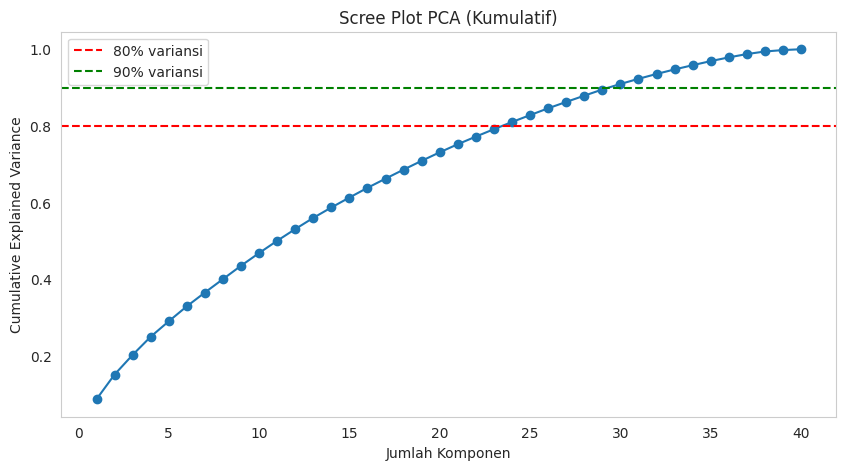

Jumlah komponen untuk capai 80% variansi: 24
Jumlah komponen untuk capai 90% variansi: 30


In [ ]:
pca_full = PCA()
pca_full.fit(X_scaled)

cum_var = pca_full.explained_variance_ratio_.cumsum()

plt.figure(figsize=(10, 5))
plt.plot(range(1, len(cum_var) + 1), cum_var, marker='o')
plt.axhline(y=0.80, color='r', linestyle='--', label='80% variansi')
plt.axhline(y=0.90, color='g', linestyle='--', label='90% variansi')
plt.xlabel("Jumlah Komponen")
plt.ylabel("Cumulative Explained Variance")
plt.title("Scree Plot PCA (Kumulatif)")
plt.legend()
plt.grid()
plt.show()

n80 = np.argmax(cum_var >= 0.80) + 1
n90 = np.argmax(cum_var >= 0.90) + 1
print(f"Jumlah komponen untuk capai 80% variansi: {n80}")
print(f"Jumlah komponen untuk capai 90% variansi: {n90}")


In [ ]:
N_COMPONENTS = n80  # bisa diganti manual, misal N_COMPONENTS = 10, jika ingin reduksi lebih agresif

pca_final = PCA(n_components=N_COMPONENTS)
X_pca = pca_final.fit_transform(X_scaled)

print("Shape sebelum PCA :", X_scaled.shape)
print("Shape setelah PCA :", X_pca.shape)
print(f"Total variansi yang dipertahankan: {pca_final.explained_variance_ratio_.sum():.2%}")


Shape sebelum PCA : (1044, 40)
Shape setelah PCA : (1044, 24)
Total variansi yang dipertahankan: 81.00%


## 7. Encode Label Target & Split Data

In [ ]:
le = LabelEncoder()
y_encoded = le.fit_transform(y)
print("Mapping kelas:", dict(zip(le.classes_, le.transform(le.classes_))))

X_train, X_test, y_train, y_test = train_test_split(
    X_pca, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded
)

print("\nData training:", X_train.shape[0])
print("Data testing :", X_test.shape[0])


Mapping kelas: {'A': np.int64(0), 'B': np.int64(1), 'C': np.int64(2), 'D': np.int64(3), 'E': np.int64(4)}

Data training: 835
Data testing : 209


## 8. Modeling — Random Forest (dengan input hasil PCA)

In [ ]:
rf_pca = RandomForestClassifier(n_estimators=300, random_state=42)
rf_pca.fit(X_train, y_train)

y_pred = rf_pca.predict(X_test)
acc_pca = accuracy_score(y_test, y_pred)

print(f"Akurasi Random Forest (dengan PCA, {N_COMPONENTS} komponen): {acc_pca:.4f}")
print()
print(classification_report(y_test, y_pred, target_names=le.classes_, zero_division=0))


Akurasi Random Forest (dengan PCA, 24 komponen): 0.3493

              precision    recall  f1-score   support

           A       0.36      0.21      0.26        24
           B       0.30      0.23      0.26        35
           C       0.37      0.23      0.29        43
           D       0.34      0.52      0.41        61
           E       0.38      0.39      0.39        46

    accuracy                           0.35       209
   macro avg       0.35      0.32      0.32       209
weighted avg       0.35      0.35      0.34       209



## 9. Confusion Matrix

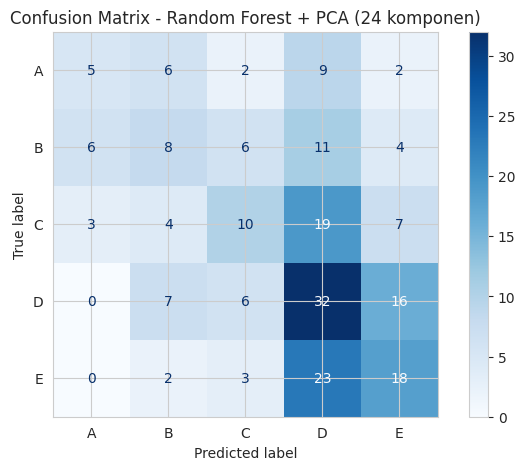

In [ ]:
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=le.classes_)
disp.plot(cmap="Blues")
plt.title(f"Confusion Matrix - Random Forest + PCA ({N_COMPONENTS} komponen)")
plt.show()


Akurasi Random Forest TANPA PCA : 0.3541
Akurasi Random Forest DENGAN PCA: 0.3493


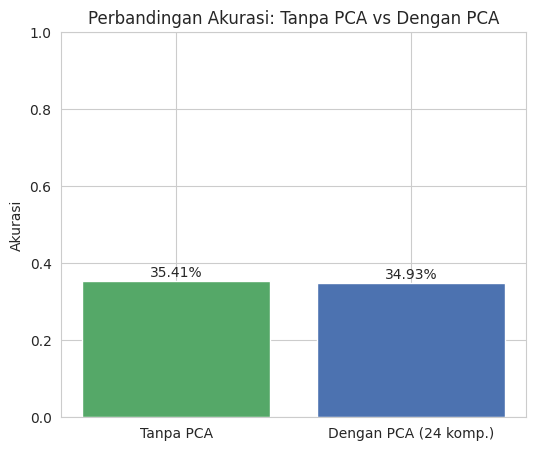

In [ ]:
X_train_raw, X_test_raw, y_train_raw, y_test_raw = train_test_split(
    X_encoded, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded
)

rf_raw = RandomForestClassifier(n_estimators=300, random_state=42)
rf_raw.fit(X_train_raw, y_train_raw)
y_pred_raw = rf_raw.predict(X_test_raw)
acc_raw = accuracy_score(y_test_raw, y_pred_raw)

print(f"Akurasi Random Forest TANPA PCA : {acc_raw:.4f}")
print(f"Akurasi Random Forest DENGAN PCA: {acc_pca:.4f}")

plt.figure(figsize=(6,5))
plt.bar(["Tanpa PCA", f"Dengan PCA ({N_COMPONENTS} komp.)"], [acc_raw, acc_pca], color=["#55A868","#4C72B0"])
plt.ylabel("Akurasi")
plt.title("Perbandingan Akurasi: Tanpa PCA vs Dengan PCA")
plt.ylim(0,1)
for i, v in enumerate([acc_raw, acc_pca]):
    plt.text(i, v+0.01, f"{v:.2%}", ha="center")
plt.show()
